# Formatos

## FiftyOne

FiftyOne es una herramienta (y framework) para:

* gestionar datasets de visión

* visualizar imágenes + anotaciones

* hacer EDA (exploración)

* depurar labels

* exportar/importar a formatos (COCO, YOLO, etc.)

La gran ventaja es que FiftyOne tiene objetos ricos como:

* `Sample` (una imagen con metadata)

* `Detections` (una lista de detecciones)

* `Detection` (un objeto con bbox, mask, label, etc.)

Y te da un dataset tipo base de datos para filtrar (views) y analizar.\n

Formato “FiftyOneDataset” en disco: un dataset está empaquetado como FiftyOneDataset suele tener:

* `samples.json` (lista de samples con fields y labels)

* `metadata.json` (info general y clases)

* `fiftyone.yml` (config)

Cómo representa bbox y máscaras FiftyOne

* Detection.bounding_box está normalizado:

  * [x, y, w, h] pero en 0..1

  * relativo a width/height de la imagen

* Detection.mask típicamente es:

  * un numpy array booleano relativo al bbox

  * la máscara es una grilla del tamaño del bbox (no de la imagen completa)


## COCO
Common Objects in Context es un formato estándar de anotación que se usa como “idioma común” para tareas de visión como:

* Detección (bounding boxes)

* Segmentación (máscaras)

* Keypoints (pose)

COCO define cómo se guarda un dataset en un JSON (y cómo se relacionan imágenes con anotaciones).

Estructura típica de un `annotations.json` COCO

Un COCO “clásico” tiene 3 listas principales:

1) ´images´
Cada entrada describe una imagen.
```json
{ "id": 123, "file_name": "images/000123.jpg", "width": 1000, "height": 584 }
```
2) `categories`
Lista de clases (categorías).
```json
{ "id": 1, "name": "scratch" }
```
3) `annotations`
Cada entrada es una instancia (un objeto) en una imagen.
```json
{ "id": 999, "image_id": 123, "category_id": 1, "bbox": [x, y, w, h], "segmentation": ..., "area": 1234, "iscrowd": 0 }
```

Bounding boxes en COCO

* bbox = [x, y, width, height]

* Siempre en pixeles

* (x, y) es la esquina superior izquierda

Segmentación (máscaras) en COCO

COCO permite 2 formas principales:

* Polígonos: lista de coordenadas [x1,y1,x2,y2,...] (puede haber varios polígonos por instancia)

* RLE (Run-Length Encoding): una codificación compacta de la máscara binaria
Esta es la que usaste: es más fiel y más compacta.

Con pycocotools:

* mask_utils.encode(mask) → genera RLE

* mask_utils.decode(rle) → vuelve a máscara binaria

Para guardar en JSON, el campo rle["counts"] suele transformarse a string ASCII.


# Pipeline

1) FiftyOne para leer y manipular correctamente

* Carga confiable desde `samples.json`

* Acceso a `det.mask` como numpy array real

* Filtrado de samples con instancias

* EDA y debugging visual

2) Convertís a COCO para entrenamiento

Muchos trainers/herramientas de segmentación (Detectron2/Mask2Former, etc.) consumen COCO directamente.
Se exporta:

* Tiles como imágenes nuevas

* `annotations.json` COCO con:

* bbox en pixeles dentro del tile

* `segmentation` como RLE dentro del tile (Run-Length Encoding comprime una máscara binaria guardando cuántos píxeles seguidos se repiten, en lugar de guardar cada píxel.)

* `category_id`


# CarDD — EDA + Tiling export (COCO) using FiftyOne

Esta notebook prepara un dataset de **segmentación por instancias** (daños en autos) a partir de CarDD:
1) Carga el dataset con **FiftyOne** (lee correctamente máscaras y bbox)
2) Visualiza bbox + contornos
3) “Tilea” imágenes a 224×224 (con solapamiento) y exporta a **COCO** (tiles + máscaras)

## COCO (resumen)
Estructura típica:
- `images`: `{id, file_name, width, height, ...}`
- `annotations`: `{id, image_id, category_id, bbox=[x,y,w,h], segmentation, area, iscrowd}`
- `categories`: `{id, name}`

En esta notebook `segmentation` se exporta como **RLE**, que es compacta y preserva detalle de la máscara.


### Celda 1 — Imports y setup del entorno

- Importa librerías generales (**NumPy/Pandas**), visualización (**Matplotlib**), IO de imágenes (**PIL**), utilidades (**tqdm**).
- Importa **FiftyOne** (`fiftyone as fo`) para cargar el dataset en formato *FiftyOneDataset* (desde `samples.json`/`metadata.json`).
- Importa **pycocotools** (`mask_utils`) para manejar **máscaras COCO** en formato **RLE (Run-Length Encoding)**.
- Configura defaults de Matplotlib.

**FiftyOne vs COCO**
- `Detection.bounding_box` (FiftyOne) está normalizado a `[x, y, w, h]` en `[0..1]`.
- `Detection.mask` (FiftyOne) es una máscara **relativa al bbox**.
- `bbox` (COCO) es `[x, y, w, h]` en **pixeles**.
- `segmentation` (COCO) puede ser **RLE** o polígonos; acá usamos **RLE**.


In [ ]:
from pathlib import Path
import os
from huggingface_hub import snapshot_download

REPO_ID = "harpreetsahota/CarDD"
REPO_TYPE = "dataset"

# Cache
BASE_DIR = Path(os.environ.get(
    "CARDD_SNAPSHOT_DIR",
    r"/Users/pablo/.cache/huggingface/hub/datasets--harpreetsahota--CarDD/snapshots/56900bde8dddfe00eb7c03114a1d46e9105e3cdb"
))

EXPORT_DIR = Path("cardd_tiles_one_49").resolve()  
IMG_DIR = EXPORT_DIR / "images"
ANN_PATH = EXPORT_DIR / "annotations.json"

if not BASE_DIR.exists():
    print(f"[INFO] Local BASE_DIR not found: {BASE_DIR}")
    print(f"[INFO] Downloading {REPO_ID} from Hugging Face hub...")

    local_path = snapshot_download(
        repo_id=REPO_ID,
        repo_type=REPO_TYPE,
    )

    BASE_DIR = Path(local_path)
    print(f"[INFO] Download complete. Using downloaded snapshot: {BASE_DIR}")

# sanity check para FiftyOneDataset
required = ["samples.json", "metadata.json", "fiftyone.yml"]
missing = [f for f in required if not (BASE_DIR / f).exists()]
assert not missing, f"Snapshot dir is missing required files {missing} at: {BASE_DIR}"

print("Using BASE_DIR:", BASE_DIR)
print("Top-level entries:", [p.name for p in sorted(BASE_DIR.iterdir())][:30])

print('metadata.json exists:', (BASE_DIR/'metadata.json').exists())
print('samples.json exists:', (BASE_DIR/'samples.json').exists())
print('fiftyone.yml exists:', (BASE_DIR/'fiftyone.yml').exists())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using BASE_DIR: /Users/pablo/.cache/huggingface/hub/datasets--harpreetsahota--CarDD/snapshots/56900bde8dddfe00eb7c03114a1d46e9105e3cdb
Top-level entries: ['.DS_Store', '.gitattributes', 'CarDD_license.pdf', 'README.md', 'cardd-overview-lq.gif', 'data', 'fiftyone.yml', 'metadata.json', 'samples.json']
metadata.json exists: True
samples.json exists: True
fiftyone.yml exists: True


### Celda 3 — Código

Ejecuta el código Python de la celda.


In [ ]:
# %pip install -U fiftyone pycocotools numpy pandas matplotlib pillow tqdm scikit-image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from skimage.measure import find_contours
from pycocotools import mask as mask_utils
import fiftyone as fo
plt.rcParams['figure.figsize'] = (10,7)
print('fiftyone:', fo.__version__)

fiftyone: 1.13.3


## Load dataset


### Celda 5 — View: filtrar samples con instancias

- Construye un `view` con samples que tienen al menos una detección en `LABEL_FIELD.detections`.
- Muestra un ejemplo y el número de detecciones.

Esto evita procesar imágenes sin etiquetas.


In [3]:
ds = fo.Dataset.from_dir(dataset_dir=str(BASE_DIR), dataset_type=fo.types.FiftyOneDataset, name='car_dd_local', overwrite=True)
print(ds)
print('Fields:', list(ds.get_field_schema().keys()))
LABEL_FIELD = 'segmentations' if 'segmentations' in ds.get_field_schema() else 'detections'
print('Using LABEL_FIELD:', LABEL_FIELD)
view = ds.match(fo.ViewField(f"{LABEL_FIELD}.detections").length() > 0)
print('Samples with instances:', len(view))


Importing samples...
 100% |███████████████| 2816/2816 [135.7ms elapsed, 0s remaining, 21.1K samples/s] 
Migrating dataset 'car_dd_local' to v1.13.3
Name:        car_dd_local
Media type:  image
Num samples: 2816
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    detections:       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    segmentations:    fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    coco_id:          fiftyone.core.fields.IntField
Fields: ['id', 'filepath', 'tags', 'metadata', 'created_at', 'last_modifie

## Sandbox: inspect a sample


### Celda 7 — `det_mask_to_full`: máscara bbox-relative → máscara full-image


FiftyOne guarda `det.mask` en coordenadas del bbox.
Esta función:
1) convierte el bbox normalizado a pixeles  
2) ajusta el tamaño de la máscara al bbox en pixeles (nearest)  
3) la “pega” en un canvas `(H, W)`

Resultado: máscara booleana alineada con la imagen completa.


In [4]:
s = view.first()
print('filepath:', s.filepath)
print('metadata:', s.metadata)
dets = s[LABEL_FIELD].detections if s[LABEL_FIELD] is not None else []
print('# detections:', len(dets))
if dets:
    d0 = dets[0]
    print('label:', d0.label)
    print('bbox:', d0.bounding_box)
    arr = None if d0.mask is None else np.asarray(d0.mask)
    print('mask:', None if arr is None else (arr.shape, arr.dtype, arr.ndim))


filepath: /Users/pablo/.cache/huggingface/hub/datasets--harpreetsahota--CarDD/snapshots/56900bde8dddfe00eb7c03114a1d46e9105e3cdb/data/000001.jpg
metadata: <ImageMetadata: {
    'size_bytes': None,
    'mime_type': None,
    'width': 1000,
    'height': 750,
    'num_channels': None,
}>
# detections: 2
label: scratch
bbox: [0.16704, 0.05361333333333333, 0.20279, 0.17512]
mask: ((132, 203), dtype('bool'), 2)


## Helper: mask to full image


### Celda 9 — Visualización: imagen + bbox + contorno de máscara

- Selecciona un sample del view (aquí se usa `skip(...)` para elegir uno determinístico).
- Dibuja bbox (rectángulo) y etiqueta por instancia.
- Convierte máscara a full-image (`det_mask_to_full`) y dibuja contornos (`find_contours`).

Sirve para validar visualmente que bbox+mask están bien alineados.


In [5]:
def det_mask_to_full(det, W, H):
    if det.mask is None:
        return None
    x,y,w,h = det.bounding_box
    x0=int(round(x*W)); y0=int(round(y*H))
    bw=max(1,int(round(w*W))); bh=max(1,int(round(h*H)))
    m=np.asarray(det.mask)
    if m.ndim==3 and m.shape[-1]==1:
        m=m[...,0]
    m=(m>0)
    if m.shape!=(bh,bw):
        m=np.asarray(Image.fromarray(m.astype(np.uint8)*255).resize((bw,bh), resample=Image.NEAREST))>0
    canvas=np.zeros((H,W), dtype=bool)
    x1=min(W,x0+bw); y1=min(H,y0+bh)
    if x1>x0 and y1>y0:
        canvas[y0:y1,x0:x1]=m[:(y1-y0),:(x1-x0)]
    return canvas


## Visualize overlays


### Celda 11 — Tiling 224×224 + export COCO (tiles)

Genera tiles y exporta un dataset en formato **COCO**:

- `generate_tiles`: recorre la imagen con stride `tile_size*(1-overlap)`.
- Para cada detección:
  - recorta la máscara full-image al tile → `m_tile`
  - filtra instancias pequeñas (`min_mask_pixels`)
  - calcula bbox desde máscara (`bbox_from_mask`) en coordenadas del tile
  - codifica la máscara a **RLE COCO** (`rle_from_mask`)

Export:
- guarda JPGs de tiles en `cardd_tiles_coco_export/images/`
- guarda `annotations.json` con `images`, `annotations`, `categories` (COCO)


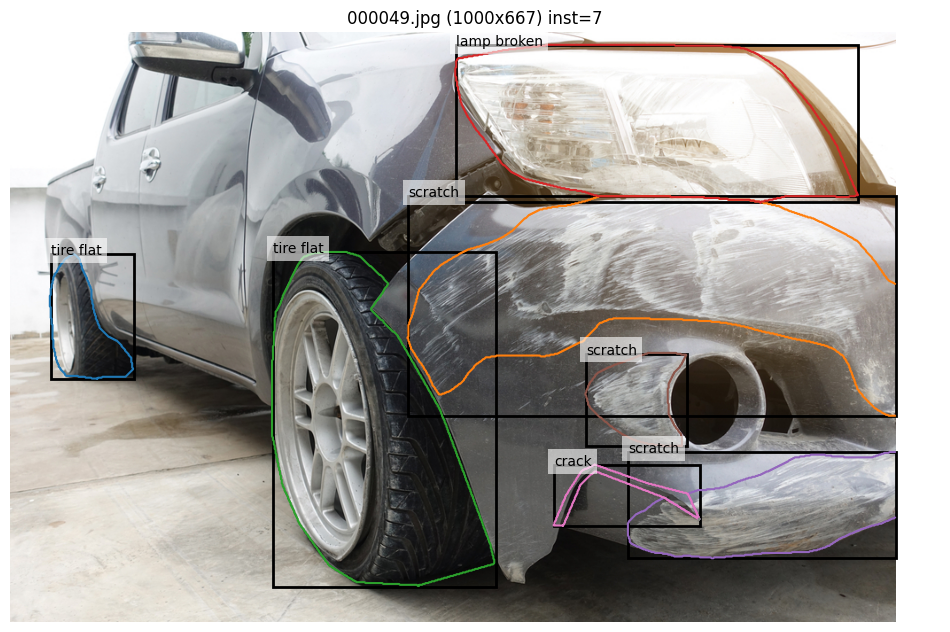

In [6]:
import random
# sample = view.take(1).first() # Selección aleatoria
sample = view.skip(32).first()
img=np.asarray(Image.open(sample.filepath).convert('RGB'))
H,W=img.shape[:2]
dets = sample[LABEL_FIELD].detections if sample[LABEL_FIELD] is not None else []
dets=dets.copy(); random.shuffle(dets); dets=dets[:15]
fig,ax=plt.subplots(figsize=(12,8)); ax.imshow(img)
ax.set_title(f'{Path(sample.filepath).name} ({W}x{H}) inst={len(dets)}')
for d in dets:
    x,y,w,h=d.bounding_box
    ax.add_patch(plt.Rectangle((x*W,y*H), w*W, h*H, fill=False, linewidth=2))
    ax.text(x*W,y*H,d.label,fontsize=10,bbox=dict(facecolor='white',alpha=0.6,edgecolor='none'))
    m_full=det_mask_to_full(d,W,H)
    if m_full is not None and m_full.any():
        for c in find_contours(m_full.astype(float),0.5):
            ax.plot(c[:,1],c[:,0],linewidth=1.5)
ax.axis('off'); plt.show()


## Tiling + COCO export (demo)


### Celda 13 — Lectura del COCO exportado + visualización desde disco

- Carga `annotations.json` y arma índices por `image_id`.
- Resuelve paths robustamente (`resolve_tile_path`).
- Abre el JPG del tile y superpone máscaras decodificadas desde RLE.

Esto muestra exactamente los tiles “que ve” el modelo en entrenamiento.


In [7]:
from dataclasses import dataclass
import json

@dataclass
class TileCfg:
    tile_size: int = 224                    # tamaño del tile (224x224) 
    overlap: float = 0.25                   # solapamiento entre tiles (25%)
    min_mask_pixels: int = 200              # filtra instancias cuya máscara en el tile sea muy chica
    # para controlar tamaño de export
    max_samples: int | None = None          # None = todo
    max_tiles_total: int | None = None      # None = sin límite
    export_empty_tiles: bool = False        # si querés negativos

def generate_tiles(W: int, H: int, tile_size: int, overlap: float):
    step = max(1, int(tile_size * (1 - overlap)))   # stride entre tiles
    for y0 in range(0, H, step):
        for x0 in range(0, W, step):
            x1 = min(W, x0 + tile_size)
            y1 = min(H, y0 + tile_size)
            # Si el tile quedó “más chico” por llegar al borde,
            # y la imagen es al menos tile_size, corrige para que sea tile_size exacto.
            if (x1 - x0) < tile_size and W >= tile_size:
                x0 = W - tile_size
                x1 = W
            if (y1 - y0) < tile_size and H >= tile_size:
                y0 = H - tile_size
                y1 = H
            yield x0, y0, x1, y1

def bbox_from_mask(mask: np.ndarray):   # Calcula un bbox COCO [x, y, w, h] en pixeles a partir de la máscara binaria del tile.
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    x0, x1 = xs.min(), xs.max() + 1
    y0, y1 = ys.min(), ys.max() + 1
    return [float(x0), float(y0), float(x1 - x0), float(y1 - y0)]

def rle_from_mask(mask: np.ndarray):    # Codifica la máscara a RLE (Run-Length Encoding) COCO.
    rle = mask_utils.encode(np.asfortranarray(mask.astype(np.uint8)))
    rle["counts"] = rle["counts"].decode("ascii")
    return rle

def export_view_to_coco_tiles(
    ds,
    view,
    label_field: str,
    out_dir: str | Path,
    img_dir: str | Path,
    cfg: TileCfg,
):
    out_dir = Path(out_dir)
    # img_dir = out_dir / "images"
    img_dir.mkdir(parents=True, exist_ok=True)
    # categorías a partir de labels observados en el dataset
    classes = sorted(set(ds.values(f"{label_field}.detections.label", unwind=True)))
    cat2id = {c: i + 1 for i, c in enumerate(classes)}
    categories = [{"id": cat2id[c], "name": c} for c in classes]

    coco = {
        "info": {"description": "CarDD tiles COCO export", "date_created": str(pd.Timestamp.utcnow())},
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": categories,
    }

    img_id = 1
    ann_id = 1
    tiles_written = 0
    # limit opcional
    base_view = view
    if cfg.max_samples is not None:
        base_view = view.limit(int(cfg.max_samples))
    for s in tqdm(base_view, total=len(base_view)):
        # leer imagen
        img = np.asarray(Image.open(s.filepath).convert("RGB"))
        H, W = img.shape[:2]
        labels = s[label_field]
        dets = labels.detections if labels is not None else []
        if not dets:
            continue
        # precompute full masks
        inst = []
        for d in dets:
            m_full = det_mask_to_full(d, W, H)
            if m_full is not None and m_full.any():
                inst.append((d.label, m_full))
        if not inst:
            continue
        stem = Path(s.filepath).stem
        for t_idx, (x0, y0, x1, y1) in enumerate(generate_tiles(W, H, cfg.tile_size, cfg.overlap)):
            tile_img = img[y0:y1, x0:x1]
            tH, tW = tile_img.shape[:2]
            tile_anns = []
            for lbl, m_full in inst:
                m_tile = m_full[y0:y1, x0:x1]
                area = int(m_tile.sum())
                if area < cfg.min_mask_pixels:
                    continue
                bbox = bbox_from_mask(m_tile)
                if bbox is None:
                    continue
                tile_anns.append({
                    "category_id": cat2id[lbl],
                    "bbox": bbox,
                    "area": float(area),
                    "iscrowd": 0,
                    "segmentation": rle_from_mask(m_tile),
                })

            if not tile_anns and not cfg.export_empty_tiles:
                continue

            fname = f"{stem}_tile_{t_idx:04d}.jpg"
            out_path = img_dir / fname
            Image.fromarray(tile_img).save(out_path, quality=95)

            coco["images"].append({
                "id": img_id,
                "file_name": f"images/{fname}",   # relativo estilo COCO
                "width": int(tW),
                "height": int(tH),
                "tile_xyxy_in_source": [int(x0), int(y0), int(x1), int(y1)],
                "source_filepath": s.filepath,
            })

            for a in tile_anns:
                coco["annotations"].append({
                    "id": ann_id,
                    "image_id": img_id,
                    **a,
                })
                ann_id += 1

            img_id += 1
            tiles_written += 1

            if cfg.max_tiles_total is not None and tiles_written >= cfg.max_tiles_total:
                break

        if cfg.max_tiles_total is not None and tiles_written >= cfg.max_tiles_total:
            break

    out_json = out_dir / "annotations.json"
    out_json.write_text(json.dumps(coco), encoding="utf-8")

    print("Export complete")
    print(" - tiles written:", tiles_written)
    print(" - images:", len(coco["images"]))
    print(" - annotations:", len(coco["annotations"]))
    print(" - out_dir:", out_dir.resolve())
    return coco

In [8]:
cfg = TileCfg(tile_size=224, overlap=0.25, min_mask_pixels=200, max_samples=None, max_tiles_total=None)
one_view = ds.select([sample.id])
coco = export_view_to_coco_tiles(ds, one_view, LABEL_FIELD, EXPORT_DIR, IMG_DIR, cfg)

/var/folders/lk/6_pk5qdn54v15_hvwxpfxrp40000gn/T/ipykernel_90722/2810413254.py:60: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "info": {"description": "CarDD tiles COCO export", "date_created": str(pd.Timestamp.utcnow())},
100%|██████████| 1/1 [00:00<00:00,  8.86it/s]

Export complete
 - tiles written: 21
 - images: 21
 - annotations: 44
 - out_dir: /Users/pablo/Downloads/cardd_tiles_one_49


In [ ]:
def show_tile_with_mask_overlay(tile, max_instances=10, alpha=0.35):
    tile_img = tile["image"]
    tH, tW = tile_img.shape[:2]
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.imshow(tile_img)
    ax.set_title(f"tile={tile['tile_index']} size={tW}x{tH} inst={len(tile['annotations'])}")
    # acumulamos todas las máscaras en una sola (para overlay)
    overlay = np.zeros((tH, tW), dtype=np.uint8)
    for ann in tile["annotations"][:max_instances]:
        x, y, w, h = ann["bbox"]
        ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, linewidth=2))
        ax.text(x, y, ann["category_name"], fontsize=10,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
        m = mask_utils.decode(ann["segmentation"])
        m = np.asarray(m)
        if m.ndim == 3:
            m = m[..., 0]
        overlay[m.astype(bool)] = 1
    ax.imshow(overlay, alpha=alpha)  # overlay en escala de grises
    ax.axis("off")
    plt.show()

tiles_with_inst: 21


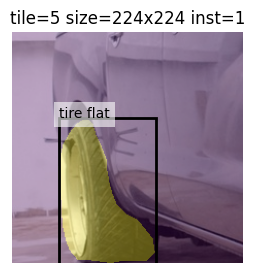

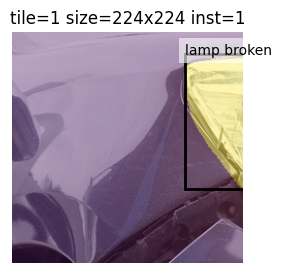

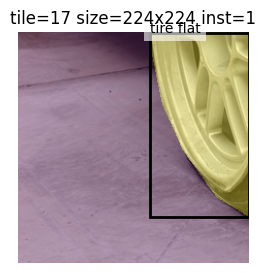

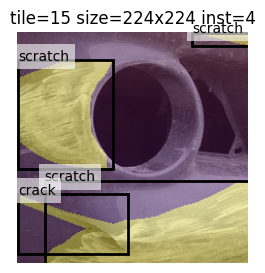

In [18]:
from collections import defaultdict

imgs_by_id = {im["id"]: im for im in coco["images"]}
cats_by_id = {c["id"]: c["name"] for c in coco["categories"]}

anns_by_img = defaultdict(list)
for a in coco["annotations"]:
    anns_by_img[a["image_id"]].append(a)

# construimos una lista tipo tiles_with_inst
tiles_with_inst = []
for image_id, anns in anns_by_img.items():
    imrec = imgs_by_id[image_id]
    img_path = EXPORT_DIR / imrec["file_name"]  # ej: images/xxx.jpg
    tile_img = np.asarray(Image.open(img_path).convert("RGB"))

    tile = {
        "tile_index": image_id,    # acá usamos image_id como id único del tile
        "image": tile_img,
        "annotations": [
            {
                "bbox": ann["bbox"],
                "category_name": cats_by_id.get(ann["category_id"], str(ann["category_id"])),
                "segmentation": ann["segmentation"],
            }
            for ann in anns
        ],
    }
    tiles_with_inst.append(tile)

print("tiles_with_inst:", len(tiles_with_inst))

N = 4
for tile in random.sample(tiles_with_inst, k=min(N, len(tiles_with_inst))):
    show_tile_with_mask_overlay(tile, alpha=0.35)

Exportar todo el DS

In [19]:
cfg = TileCfg(tile_size=224, overlap=0.25, min_mask_pixels=200, max_samples=None, max_tiles_total=None)
coco_full = export_view_to_coco_tiles(ds, view, LABEL_FIELD, EXPORT_DIR, IMG_DIR, cfg)

/var/folders/lk/6_pk5qdn54v15_hvwxpfxrp40000gn/T/ipykernel_90722/2810413254.py:60: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "info": {"description": "CarDD tiles COCO export", "date_created": str(pd.Timestamp.utcnow())},
100%|██████████| 2816/2816 [03:45<00:00, 12.48it/s]


Export complete
 - tiles written: 44127
 - images: 44127
 - annotations: 53354
 - out_dir: /Users/pablo/Downloads/cardd_tiles_one_49


## EDA adicional (dataset original y tiles exportados)

Este EDA calcula estadísticas tanto del dataset original (vía FiftyOne) como del dataset tileado (vía COCO exportado).


In [12]:
EDA_MAX_SAMPLES = None  # None = todos; p.ej. 500 para un EDA rápido

### FiftyOne

In [13]:
from collections import Counter
from collections import defaultdict

# Asegurar metadata (width/height)
try:
    _ = ds.first().metadata.width
except Exception:
    ds.compute_metadata()

base_view = view
if EDA_MAX_SAMPLES is not None:
    base_view = view.limit(int(EDA_MAX_SAMPLES))

rows = []
for s in tqdm(base_view, total=len(base_view)):
    W, H = s.metadata.width, s.metadata.height
    labels = s[LABEL_FIELD]
    dets = labels.detections if labels is not None else []
    for d in dets:
        x, y, w, h = d.bounding_box
        bw = w * W
        bh = h * H
        bbox_area = bw * bh

        m_full = det_mask_to_full(d, W, H)
        mask_area = int(m_full.sum()) if (m_full is not None) else 0

        rows.append({
            "filepath": s.filepath,
            "width": W,
            "height": H,
            "pixels": W * H,
            "label": d.label,
            "bbox_w": bw,
            "bbox_h": bh,
            "bbox_area": bbox_area,
            "mask_area": mask_area,
        })

df_eda = pd.DataFrame(rows)
display(df_eda.head())
print("Samples in EDA view:", len(base_view))
print("Instances:", len(df_eda))
print("Classes:", df_eda['label'].nunique())


100%|██████████| 2816/2816 [00:12<00:00, 233.64it/s]


,filepath,width,height,pixels,label,bbox_w,bbox_h,bbox_area,mask_area
0,/Users/pablo/.cache/huggingface/hub/datasets--...,1000,750,750000,scratch,202.79,131.34,26634.4386,13444
1,/Users/pablo/.cache/huggingface/hub/datasets--...,1000,750,750000,tire flat,684.19,551.02,377002.3738,298742
2,/Users/pablo/.cache/huggingface/hub/datasets--...,1000,667,667000,tire flat,397.20,346.68,137701.2960,114126
3,/Users/pablo/.cache/huggingface/hub/datasets--...,1000,667,667000,tire flat,645.71,521.12,336492.3952,299792
4,/Users/pablo/.cache/huggingface/hub/datasets--...,1000,667,667000,tire flat,718.62,649.69,466880.2278,383763


Samples in EDA view: 2816
Instances: 6211
Classes: 6


,instances
label,
scratch,2560
dent,1806
crack,651
lamp broken,494
glass shatter,475
tire flat,225


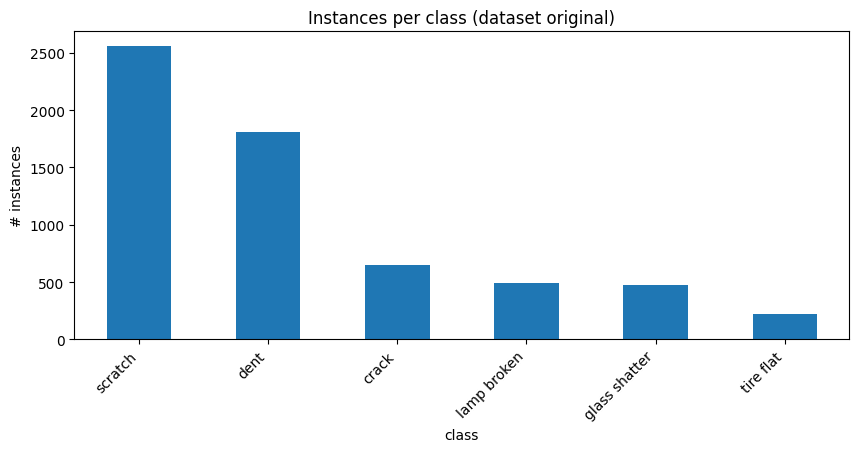

In [14]:
# Distribución de clases (instancias)
class_counts = df_eda["label"].value_counts()
display(class_counts.to_frame("instances"))

fig, ax = plt.subplots(figsize=(10,4))
class_counts.plot(kind="bar", ax=ax)
ax.set_title("Instances per class (dataset original)")
ax.set_xlabel("class")
ax.set_ylabel("# instances")
plt.xticks(rotation=45, ha="right")
plt.show()


,width,height,pixels
count,2816.000000,2816.000000,2816.000000
mean,978.997514,705.300781,684298.295455
std,77.448657,97.174243,55298.265792
min,562.000000,333.000000,333000.000000
25%,1000.000000,667.000000,667000.000000
50%,1000.000000,667.000000,667000.000000
75%,1000.000000,750.000000,673000.000000
max,1000.000000,1000.000000,1000000.000000


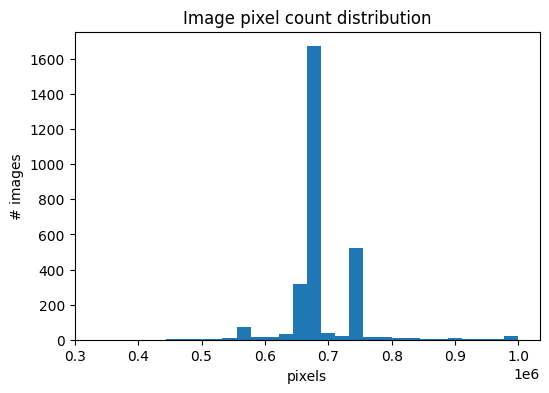

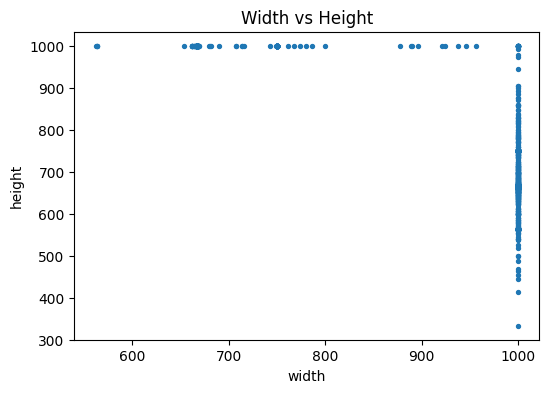

In [15]:
# Tamaños de imagen (únicos por filepath)
df_img = df_eda.drop_duplicates("filepath")[["width","height","pixels"]]
display(df_img.describe())

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df_img["pixels"], bins=30)
ax.set_title("Image pixel count distribution")
ax.set_xlabel("pixels")
ax.set_ylabel("# images")
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df_img["width"], df_img["height"], s=8)
ax.set_title("Width vs Height")
ax.set_xlabel("width")
ax.set_ylabel("height")
plt.show()


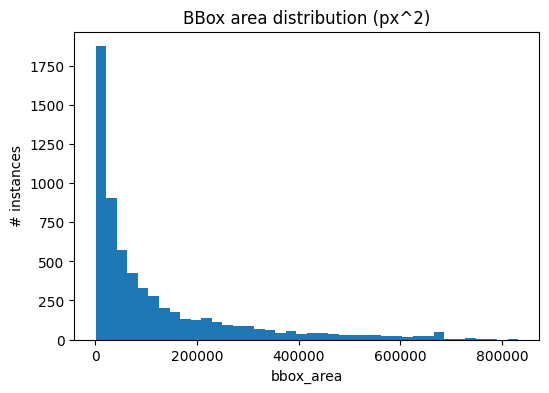

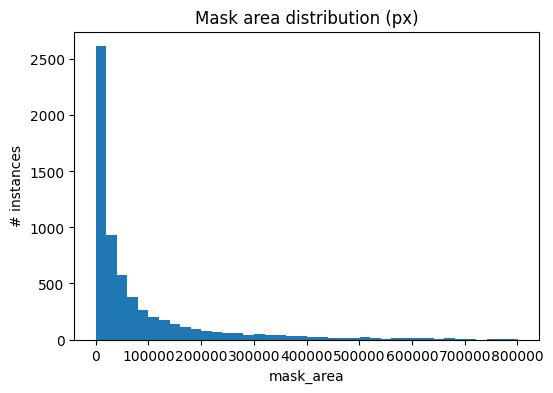

count    6211.000000
mean        0.592306
std         0.200210
min         0.026626
25%         0.474354
50%         0.626936
75%         0.738971
max         1.000000
Name: mask_to_bbox_ratio, dtype: float64

In [16]:
# Distribución de áreas bbox / máscara
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df_eda["bbox_area"], bins=40)
ax.set_title("BBox area distribution (px^2)")
ax.set_xlabel("bbox_area")
ax.set_ylabel("# instances")
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df_eda["mask_area"], bins=40)
ax.set_title("Mask area distribution (px)")
ax.set_xlabel("mask_area")
ax.set_ylabel("# instances")
plt.show()

df_eda["mask_to_bbox_ratio"] = df_eda["mask_area"] / df_eda["bbox_area"].clip(lower=1.0)
display(df_eda["mask_to_bbox_ratio"].describe())


### COCO export (EDA del dataset tileado)

Tiles images: 44127
Tiles annotations: 53354
Tiles categories: 6


count    44127.000000
mean         1.209101
std          0.516983
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: instances_per_tile, dtype: float64

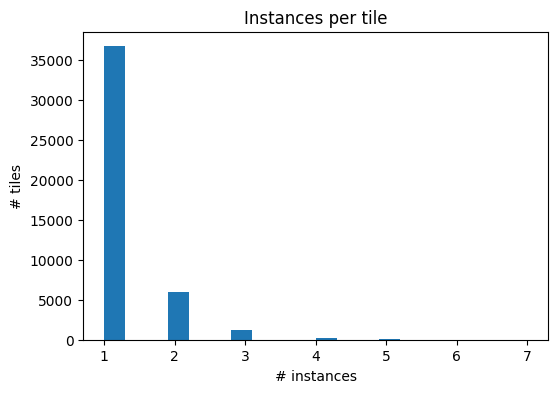

,instances
scratch,17987
dent,14180
glass shatter,9683
lamp broken,5541
tire flat,3660
crack,2303


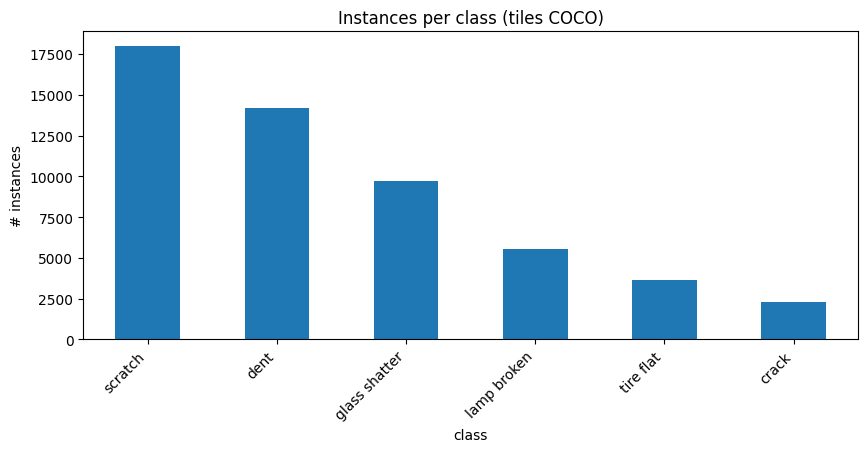

In [20]:
assert ANN_PATH.exists(), f"No COCO export found at {ANN_PATH}. Run the tiling/export cell first."

coco_tiles = json.loads(ANN_PATH.read_text(encoding="utf-8"))
imgs = coco_tiles["images"]
anns = coco_tiles["annotations"]
cats = {c["id"]: c["name"] for c in coco_tiles["categories"]}

print("Tiles images:", len(imgs))
print("Tiles annotations:", len(anns))
print("Tiles categories:", len(cats))

anns_by_img = defaultdict(list)
for a in anns:
    anns_by_img[a["image_id"]].append(a)

inst_per_tile = pd.Series([len(anns_by_img[im["id"]]) for im in imgs], name="instances_per_tile")
display(inst_per_tile.describe())

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(inst_per_tile, bins=20)
ax.set_title("Instances per tile")
ax.set_xlabel("# instances")
ax.set_ylabel("# tiles")
plt.show()

tile_class_counts = Counter([cats[a["category_id"]] for a in anns])
tile_class_counts = pd.Series(tile_class_counts).sort_values(ascending=False)
display(tile_class_counts.to_frame("instances"))

fig, ax = plt.subplots(figsize=(10,4))
tile_class_counts.plot(kind="bar", ax=ax)
ax.set_title("Instances per class (tiles COCO)")
ax.set_xlabel("class")
ax.set_ylabel("# instances")
plt.xticks(rotation=45, ha="right")
plt.show()


,image_id,tile_w,tile_h,tile_area,instances,mask_area_sum,coverage
0,1,224,224,50176,1,5010.0,0.099849
1,2,224,224,50176,2,36934.0,0.736089
2,3,224,224,50176,2,44401.0,0.884905
3,4,224,224,50176,2,26988.0,0.537867
4,5,224,224,50176,1,7431.0,0.148099


count    21.000000
mean      0.447271
std       0.250686
min       0.081114
25%       0.242347
50%       0.399574
75%       0.694774
max       0.884905
Name: coverage, dtype: float64

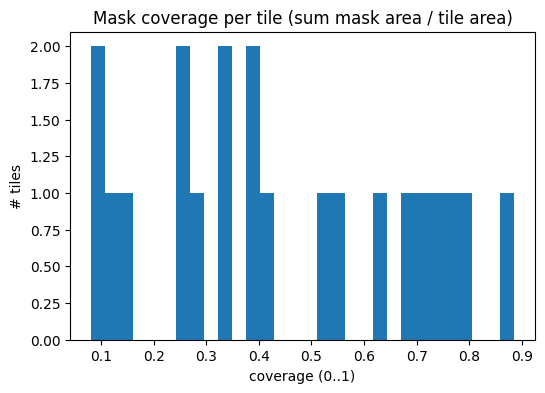

0.50    0.399574
0.75    0.694774
0.90    0.755481
0.95    0.790697
0.99    0.866063
Name: coverage, dtype: float64


In [22]:
# coco: dict leído de annotations.json
imgs = coco["images"]
anns = coco["annotations"]

anns_by_img = defaultdict(list)
for a in anns:
    anns_by_img[a["image_id"]].append(a)

rows = []
for im in imgs:
    img_id = im["id"]
    tile_area = im["width"] * im["height"]  # tile_w * tile_h (pixeles)
    mask_area = sum(a.get("area", 0) for a in anns_by_img.get(img_id, []))
    coverage = (mask_area / tile_area) if tile_area > 0 else 0.0

    rows.append({
        "image_id": img_id,
        "tile_w": im["width"],
        "tile_h": im["height"],
        "tile_area": tile_area,
        "instances": len(anns_by_img.get(img_id, [])),
        "mask_area_sum": mask_area,
        "coverage": coverage,   # 0..1
    })

df_cov = pd.DataFrame(rows)

display(df_cov.head())
display(df_cov["coverage"].describe())

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df_cov["coverage"], bins=30)
ax.set_title("Mask coverage per tile (sum mask area / tile area)")
ax.set_xlabel("coverage (0..1)")
ax.set_ylabel("# tiles")
plt.show()

# percentiles útiles
print(df_cov["coverage"].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))